# Week 4, Day 1
## Problem Framing, Hold-Out Test & Baseline (UCI Adult / Census Income)

1. Frame the business problem and pick a metric
2. Load and explore the data
3. Build a proper train/hold-out split (so we can trust our final numbers)
4. Build two "baseline" models: dumb-but-honest yardsticks
5. Look at where the baseline gets things wrong


## Task 1: Problem Definition & Success Metrics

* **Business Goal:** Efficiently target outreach (calls/mailers) for a premium financial product.
* **Target Class:** `income > 50K` (encoded as `1`); all others `0`.
* **Primary Metric: Precision.** Every contact costs money. We prioritize precision to avoid cash-burning false positives (contacting unqualified leads). Missed high earners (false negatives) are acceptable opportunity costs.
* **Secondary Metric: ROC AUC.** Used as a threshold-independent check of model quality. F1 is tracked but ignored for optimization, as it incorrectly treats false positives and false negatives as equally costly.
* **Stakeholder Bottom Line:** Maximize the success rate of the outreach budget. It is better to occasionally miss a good lead than consistently pay to contact bad ones.

In [39]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import fetch_openml
import os

os.makedirs('charts', exist_ok=True)

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, average_precision_score, confusion_matrix,
    ConfusionMatrixDisplay, classification_report
)

RANDOM_STATE = 42   # fixed seed -> same split every time we re-run this notebook
pd.set_option('display.max_columns', 50)
sns.set_theme(style="whitegrid")


## Task 2: Data Load & Quick EDA


**Missing values:** this dataset marks missing entries with the string `'?'` instead of a
proper NaN. We convert those to real NaN so pandas/sklearn treat them as missing (and so
`.isna()` actually finds them).


In [40]:
# Column names, per the official UCI documentation for this dataset
column_names = [
"age", "workclass", "fnlwgt", "education", "education-num",
    "marital-status", "occupation", "relationship", "race", "sex",
    "capital-gain", "capital-loss", "hours-per-week", "native-country", "income"
]

dataset = fetch_openml('adult', version=2, as_frame=True)
df = dataset.frame

df.replace('?', np.nan, inplace=True)

print("Shape:", df.shape)
df.head()

Shape: (48842, 15)


,age,workclass,fnlwgt,education,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country,class
0,25,Private,226802,11th,7,Never-married,Machine-op-inspct,Own-child,Black,Male,0,0,40,United-States,<=50K
1,38,Private,89814,HS-grad,9,Married-civ-spouse,Farming-fishing,Husband,White,Male,0,0,50,United-States,<=50K
2,28,Local-gov,336951,Assoc-acdm,12,Married-civ-spouse,Protective-serv,Husband,White,Male,0,0,40,United-States,>50K
3,44,Private,160323,Some-college,10,Married-civ-spouse,Machine-op-inspct,Husband,Black,Male,7688,0,40,United-States,>50K
4,18,NaN,103497,Some-college,10,Never-married,NaN,Own-child,White,Female,0,0,30,United-States,<=50K


In [41]:
# uncomment the line below if data is raw because openml parser already converts '?' to NaN when it loads the data
# df = df.replace('?', np.nan)

df.rename(columns={'class': 'income'}, inplace=True)


df["income"] = df["income"].str.strip().str.rstrip(".")
df["target"] = (df["income"] == ">50K").astype(int)

df[["income", "target"]].drop_duplicates()
df.head(5)

,age,workclass,fnlwgt,education,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country,income,target
0,25,Private,226802,11th,7,Never-married,Machine-op-inspct,Own-child,Black,Male,0,0,40,United-States,<=50K,0
1,38,Private,89814,HS-grad,9,Married-civ-spouse,Farming-fishing,Husband,White,Male,0,0,50,United-States,<=50K,0
2,28,Local-gov,336951,Assoc-acdm,12,Married-civ-spouse,Protective-serv,Husband,White,Male,0,0,40,United-States,>50K,1
3,44,Private,160323,Some-college,10,Married-civ-spouse,Machine-op-inspct,Husband,Black,Male,7688,0,40,United-States,>50K,1
4,18,NaN,103497,Some-college,10,Never-married,NaN,Own-child,White,Female,0,0,30,United-States,<=50K,0


In [42]:
# Column types and missingness
print(df.dtypes)
missing = df.isna().sum()
print(missing,"\n")
missing = missing[missing > 0].sort_values(ascending=False)
print("Columns with missing values:")
print(missing)
print(f"Total missing cells: {df.isna().sum().sum()} "
      f"({df.isna().sum().sum() / df.size} of all cells)")


age                  int64
workclass         category
fnlwgt               int64
education         category
education-num        int64
marital-status    category
occupation        category
relationship      category
race              category
sex               category
capital-gain         int64
capital-loss         int64
hours-per-week       int64
native-country    category
income              object
target               int64
dtype: object
age                  0
workclass         2799
fnlwgt               0
education            0
education-num        0
marital-status       0
occupation        2809
relationship         0
race                 0
sex                  0
capital-gain         0
capital-loss         0
hours-per-week       0
native-country     857
income               0
target               0
dtype: int64 

Columns with missing values:
occupation        2809
workclass         2799
native-country     857
dtype: int64
Total missing cells: 6465 (0.008272849187174972 of all cells

In [43]:
# Numeric data
numeric_cols = ["age", "fnlwgt", "education-num", "capital-gain", "capital-loss", "hours-per-week"]
df[numeric_cols].describe()

,age,fnlwgt,education-num,capital-gain,capital-loss,hours-per-week
count,48842.000000,4.884200e+04,48842.000000,48842.000000,48842.000000,48842.000000
mean,38.643585,1.896641e+05,10.078089,1079.067626,87.502314,40.422382
std,13.710510,1.056040e+05,2.570973,7452.019058,403.004552,12.391444
min,17.000000,1.228500e+04,1.000000,0.000000,0.000000,1.000000
25%,28.000000,1.175505e+05,9.000000,0.000000,0.000000,40.000000
50%,37.000000,1.781445e+05,10.000000,0.000000,0.000000,40.000000
75%,48.000000,2.376420e+05,12.000000,0.000000,0.000000,45.000000
max,90.000000,1.490400e+06,16.000000,99999.000000,4356.000000,99.000000


In [44]:
for col in ["workclass", "education", "marital-status", "occupation", "sex", "race"]:
    print(f" ###  {col} ")
    print(df[col].value_counts(dropna=False).head(8))


 ###  workclass 
workclass
Private             33906
Self-emp-not-inc     3862
Local-gov            3136
NaN                  2799
State-gov            1981
Self-emp-inc         1695
Federal-gov          1432
Without-pay            21
Name: count, dtype: int64
 ###  education 
education
HS-grad         15784
Some-college    10878
Bachelors        8025
Masters          2657
Assoc-voc        2061
11th             1812
Assoc-acdm       1601
10th             1389
Name: count, dtype: int64
 ###  marital-status 
marital-status
Married-civ-spouse       22379
Never-married            16117
Divorced                  6633
Separated                 1530
Widowed                   1518
Married-spouse-absent      628
Married-AF-spouse           37
Name: count, dtype: int64
 ###  occupation 
occupation
Prof-specialty       6172
Craft-repair         6112
Exec-managerial      6086
Adm-clerical         5611
Sales                5504
Other-service        4923
Machine-op-inspct    3022
NaN                

In [45]:
# Class base rate -- how many people actually earn >50K?
base_rate = df["target"].mean()
class_counts = df["target"].value_counts().rename({0: "<=50K", 1: ">50K"})
print(class_counts)
print(f"\nBase rate (positive class share): {base_rate:.2%}")


target
<=50K    37155
>50K     11687
Name: count, dtype: int64

Base rate (positive class share): 23.93%


This base rate matters a lot: it's our nothing point. If around 24% of people
earn >50K, then a model that always guesses "<=50K" is already 76% accurate which is
why accuracy alone is a misleading metric for this problem. 


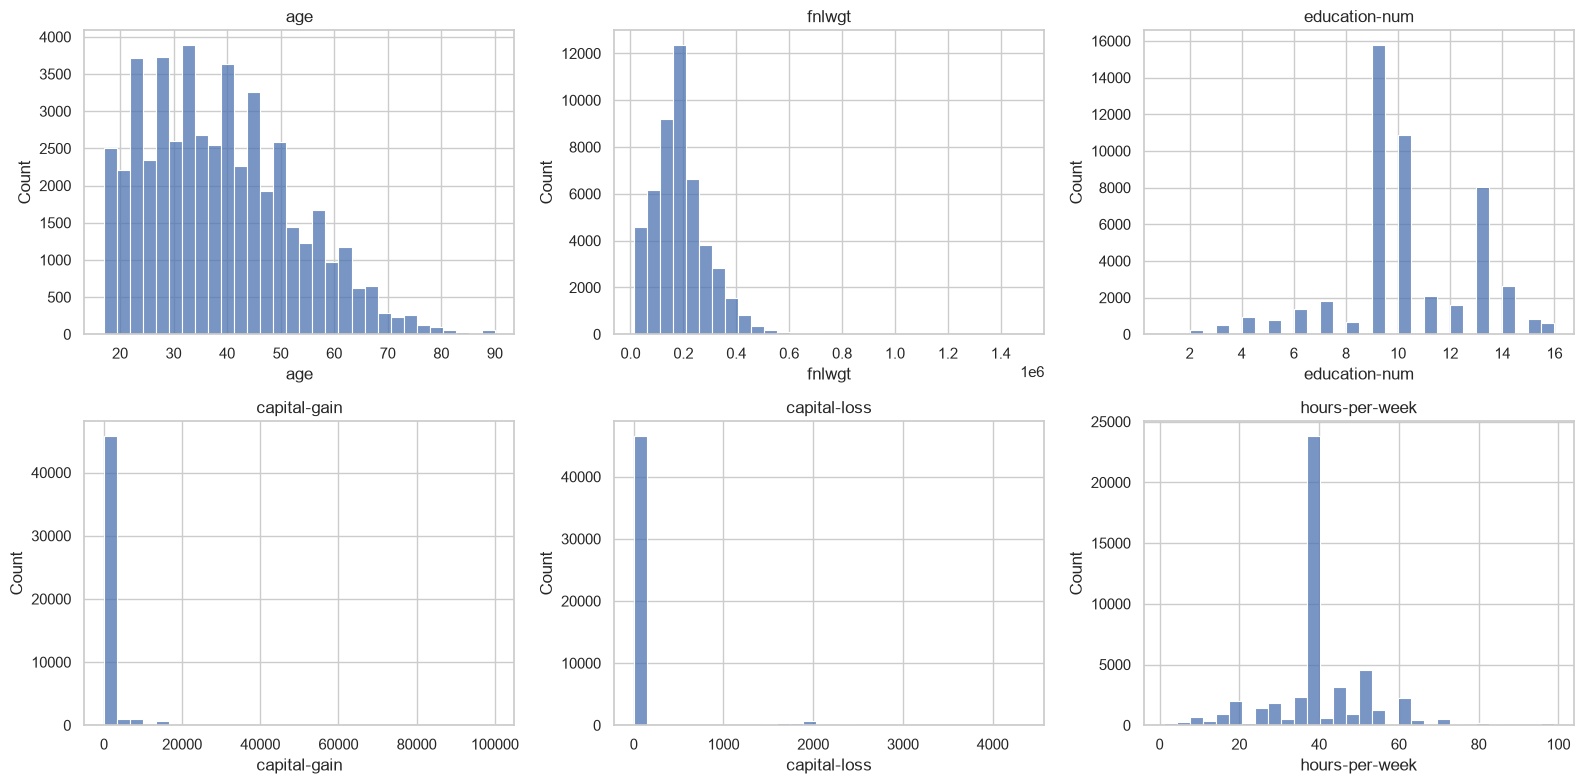

In [46]:
# Visualizations: histograms for numeric features 
fig, axes = plt.subplots(2, 3, figsize=(16, 8))
for ax, col in zip(axes.flat, numeric_cols):
    sns.histplot(df[col], bins=30, ax=ax)
    ax.set_title(col)
plt.tight_layout()
plt.savefig("charts/Numeric_histograms.png")
plt.show()


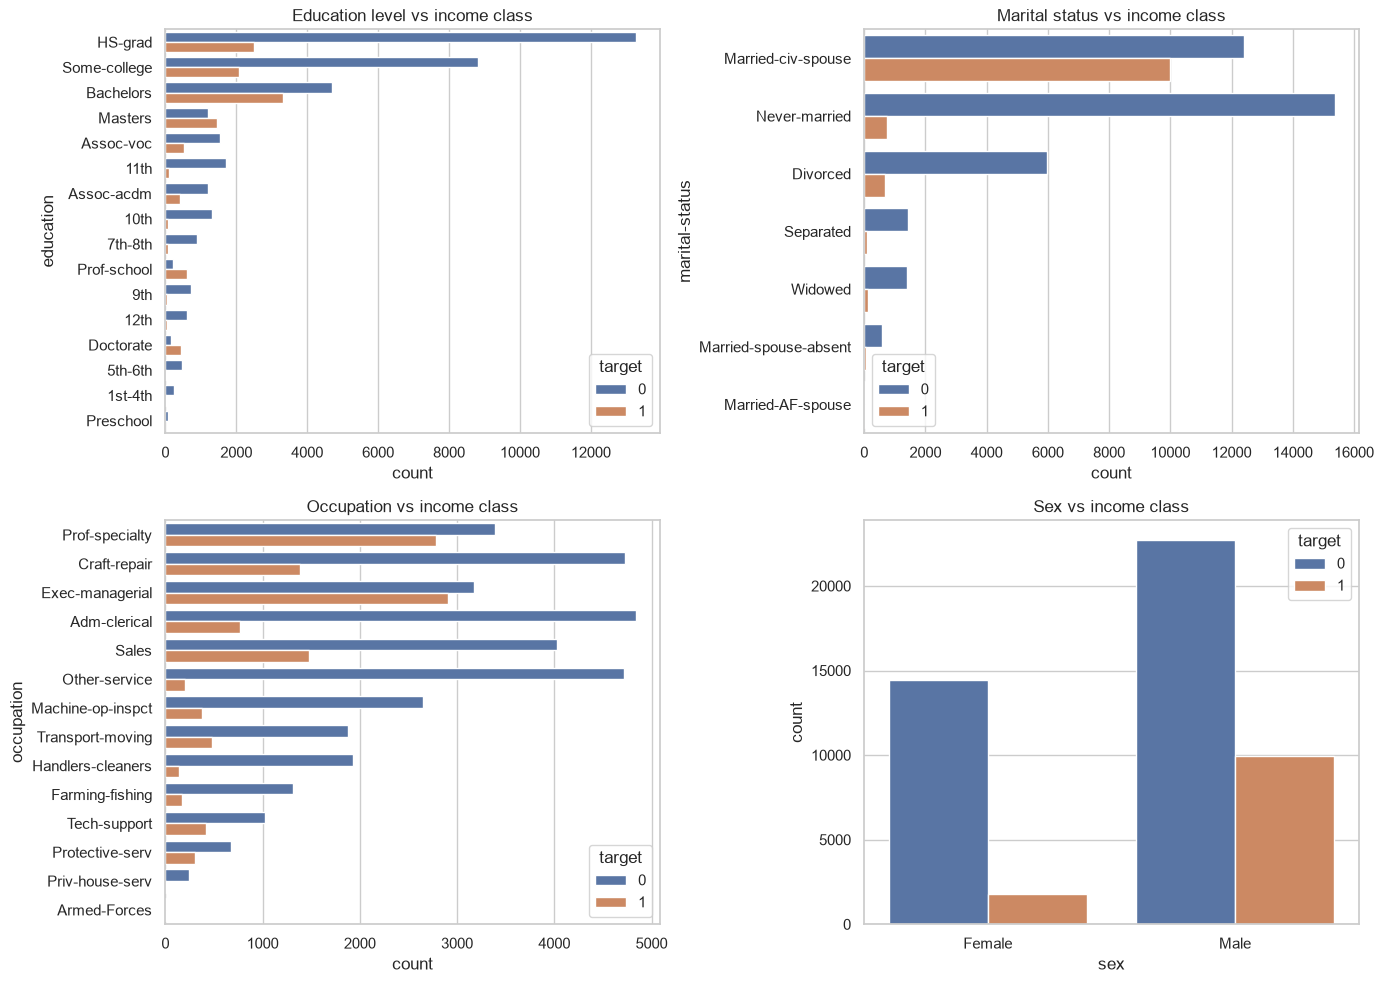

In [47]:
# categorical columns visualization with bar plots

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

sns.countplot(data=df, y="education", order=df["education"].value_counts().index,
              hue="target", ax=axes[0, 0])
axes[0, 0].set_title("Education level vs income class")

sns.countplot(data=df, y="marital-status", order=df["marital-status"].value_counts().index,
              hue="target", ax=axes[0, 1])
axes[0, 1].set_title("Marital status vs income class")

sns.countplot(data=df, y="occupation", order=df["occupation"].value_counts().index,
              hue="target", ax=axes[1, 0])
axes[1, 0].set_title("Occupation vs income class")

sns.countplot(data=df, x="sex", hue="target", ax=axes[1, 1])
axes[1, 1].set_title("Sex vs income class")

plt.tight_layout()
plt.savefig("charts/categorical_bars.png")
plt.show()


In [48]:
# Summary table: class counts + a few notable feature distributions, saved for the report
summary_rows = []
summary_rows.append({"metric": "Total rows", "value": len(df)})
summary_rows.append({"metric": "Positive class", "value": int((df.target == 1).sum())})
summary_rows.append({"metric": "Negative class", "value": int((df.target == 0).sum())})
summary_rows.append({"metric": "Base rate", "value": f"{base_rate}"})
summary_rows.append({"metric": "Mean age", "value": round(df['age'].mean(), 1)})
summary_rows.append({"metric": "Mean hours-per-week", "value": round(df['hours-per-week'].mean(), 1)})
summary_rows.append({"metric": "capital-gain > 0", "value": f"{(df['capital-gain'] > 0).mean()}"})
summary_rows.append({"metric": "Bachelors+)", "value": f"{(df['education-num'] >= 13).mean()}"})
summary_rows.append({"metric": "Missing data 'workclass'", "value": int(df['workclass'].isna().sum())})
summary_rows.append({"metric": "Missing data'occupation'", "value": int(df['occupation'].isna().sum())})
summary_rows.append({"metric": "Missing data'native-country'", "value": int(df['native-country'].isna().sum())})

summary_df = pd.DataFrame(summary_rows)
summary_df.to_csv("charts/Summary_Table.csv", index=False)
summary_df


,metric,value
0,Total rows,48842
1,Positive class,11687
2,Negative class,37155
3,Base rate,0.23928176569346055
4,Mean age,38.6
5,Mean hours-per-week,40.4
6,capital-gain > 0,0.08261332459768232
7,Bachelors+),0.2479423447033291
8,Missing data 'workclass',2799
9,Missing data'occupation',2809


## Task 3: Create Reproducible Splits

* **Prevent Data Leakage:** Isolate a hold-out test set before any EDA or modeling. Tuning a model on the same data used for evaluation causes it to memorize patterns (overfit), artificially inflating performance metrics.
* **Strict Isolation:** The test set is locked away until final reporting. All exploration, feature engineering, and tuning must happen exclusively on the training data.
* **Stratified Splitting (`stratify=target`):** Preserves the dataset's original ~24%/76% class balance, ensuring the hold-out set has enough positive examples for a reliable evaluation.
* **Reproducibility (`random_state=42`):** Anchors the random seed so the notebook generates the exact same data split every time it runs.

In [49]:
# 80% train+dev and 20% hold-out test
train_dev_df, test_df = train_test_split(
    df, test_size=0.20, stratify=df["target"], random_state=RANDOM_STATE
)

#further opt-split: carve a dev set out of the remaining 80%
train_df, dev_df = train_test_split(
    train_dev_df, test_size=0.125, stratify=train_dev_df["target"], random_state=RANDOM_STATE
)

print(f"Train size: {len(train_df)}  ({len(train_df)/len(df)} of full data)")
print(f"Dev size:   {len(dev_df)}   ({len(dev_df)/len(df)} of full data)")
print(f"Test size:  {len(test_df)}  ({len(test_df)/len(df)} of full data)")
print()
print("Class balance check (share of positives in each split):")
for name, part in [("Full data", df), ("Train", train_df), ("Dev", dev_df), ("Test (hold-out)", test_df)]:
    print(f"  {name} : {part['target'].mean():.2%}")


Train size: 34188  (0.699971336145121 of full data)
Dev size:   4885   (0.10001637934564514 of full data)
Test size:  9769  (0.20001228450923386 of full data)

Class balance check (share of positives in each split):
  Full data : 23.93%
  Train : 23.93%
  Dev : 23.93%
  Test (hold-out) : 23.93%


## Task 4: Implement Simple Baselines

Baselines establish the minimum performance bar. If a complex model cannot outperform these deliberately simple rules, it isn't worth using.

* **Baseline 1 (Majority-Class Predictor):** Always predicts `<=50K`. This establishes the absolute minimum "zero-effort" scenario.
* **Baseline 2 (Heuristic Rule):** Predicts `>50K` if `education-num >= 13` (Bachelor's degree or higher) OR `capital-gain > 0`. This provides a logical benchmark grounded in the strong real-world correlations between high income, advanced education, and investment wealth.

In [50]:
# Majority-class predictor
majority_class = train_df["target"].mode()[0]
print(f"Majority class in training data: {majority_class} "
      f"({'<=50K' if majority_class == 0 else '>50K'})")

y_test = test_df["target"].values
y_pred_majority = np.full_like(y_test, fill_value=majority_class)

y_score_majority = y_pred_majority.astype(float)


Majority class in training data: 0 (<=50K)


In [51]:
# Single-feature rule
# Rule: predict True if education-num >= 13 OR capital_gain > 0
def rule_predict(frame):
    return ((frame["education-num"] >= 13) | (frame["capital-gain"] > 0)).astype(int)

y_pred_rule = rule_predict(test_df).values
# A simple continuous "score" version for ROC/PR AUC: combine both signals into one number
y_score_rule = (
    (test_df["education-num"] / test_df["education-num"].max()) * 0.5
    + (test_df["capital-gain"] > 0).astype(float) * 0.5
).values


In [52]:
def evaluate(y_true, y_pred, y_score, name):
    return {
        "model": name,
        "accuracy": accuracy_score(y_true, y_pred),
        "precision": precision_score(y_true, y_pred, zero_division=0),
        "recall": recall_score(y_true, y_pred, zero_division=0),
        "f1": f1_score(y_true, y_pred, zero_division=0),
        "roc_auc": roc_auc_score(y_true, y_score),
        "pr_auc": average_precision_score(y_true, y_score),
    }

results = [
    evaluate(y_test, y_pred_majority, y_score_majority, "Majority-class"),
    evaluate(y_test, y_pred_rule, y_score_rule, "Rule-based (education-num>=13 OR capital-gain>0)"),
]
results_df = pd.DataFrame(results).set_index("model").round(4)
results_df.to_csv("charts/base_metrics.csv")
results_df


,accuracy,precision,recall,f1,roc_auc,pr_auc
model,,,,,,
Majority-class,0.7607,0.0000,0.0000,0.0000,0.5000,0.2393
Rule-based (education-num>=13 OR capital-gain>0),0.7520,0.4852,0.5967,0.5352,0.7493,0.5079


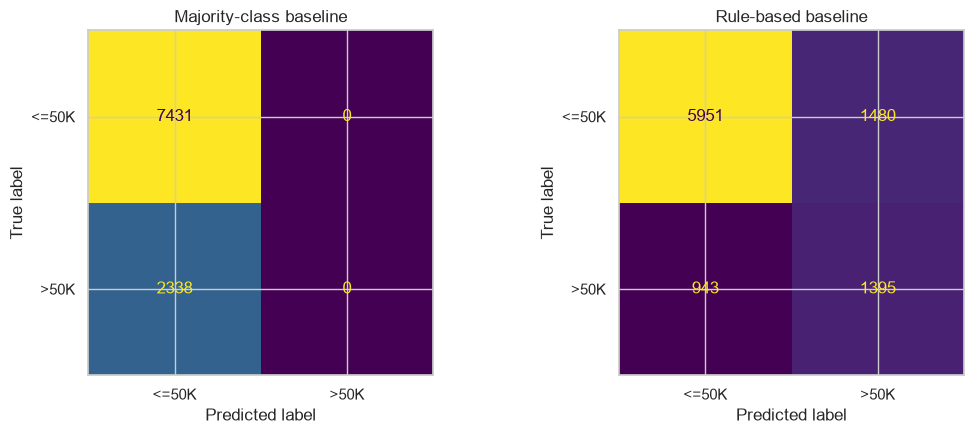

In [53]:
# Confusion matrices for both baselines
fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))

cm_majority = confusion_matrix(y_test, y_pred_majority)
ConfusionMatrixDisplay(cm_majority, display_labels=["<=50K", ">50K"]).plot(ax=axes[0], colorbar=False)
axes[0].set_title("Majority-class baseline")

cm_rule = confusion_matrix(y_test, y_pred_rule)
ConfusionMatrixDisplay(cm_rule, display_labels=["<=50K", ">50K"]).plot(ax=axes[1], colorbar=False)
axes[1].set_title("Rule-based baseline")

plt.tight_layout()
plt.savefig("charts/baseline_confusion_matrices.png")
plt.show()


**Baseline Interpretation & Takeaways**

* **Majority-Class Flaws:** Achieves ~76% raw accuracy but yields zero precision and recall for the positive class. Because it never flags high earners, it is entirely useless for our business objective.
* **Rule-Based Superiority:** Captures actual data signals, generating non-zero precision/recall and higher AUC scores. It wins on all metrics that matter, perfectly illustrating why raw accuracy is a misleading metric for this dataset.
* **The Threshold for Success:** To justify the cost of added complexity, any future machine learning model must clearly outperform the rule-based baseline—specifically improving ROC AUC and beating its F1 score by a meaningful margin (+0.05 to +0.10).

## Task 5: Initial Error Analysis


In [54]:
test_analysis = test_df.copy()
test_analysis["pred"] = y_pred_rule
test_analysis["true"] = y_test

false_positives = test_analysis[(test_analysis["pred"] == 1) & (test_analysis["true"] == 0)]
false_negatives = test_analysis[(test_analysis["pred"] == 0) & (test_analysis["true"] == 1)]

print(f"False positives: {len(false_positives)}")
print(f"False negatives: {len(false_negatives)}")

cols_to_show = ["age", "workclass", "education", "education-num", "marital-status",
                 "occupation", "capital-gain", "capital-loss", "hours-per-week", "sex", "income"]

print("\nSample false positives (predicted >50K, actually <=50K):")
display(false_positives[cols_to_show].sample(12, random_state=RANDOM_STATE))


False positives: 1480
False negatives: 943

Sample false positives (predicted >50K, actually <=50K):


,age,workclass,education,education-num,marital-status,occupation,capital-gain,capital-loss,hours-per-week,sex,income
31242,35,Private,Bachelors,13,Married-civ-spouse,Sales,0,0,50,Male,<=50K
866,40,Federal-gov,Bachelors,13,Married-civ-spouse,Exec-managerial,0,0,39,Male,<=50K
19163,53,Private,Bachelors,13,Married-civ-spouse,Exec-managerial,0,0,40,Male,<=50K
39000,26,Private,Bachelors,13,Never-married,Sales,0,0,50,Male,<=50K
46155,63,Local-gov,Bachelors,13,Married-civ-spouse,Transport-moving,0,0,40,Male,<=50K
29664,32,Self-emp-inc,Bachelors,13,Married-civ-spouse,Sales,0,0,45,Male,<=50K
47129,17,Private,11th,7,Never-married,Craft-repair,594,0,40,Male,<=50K
36843,43,Self-emp-not-inc,Bachelors,13,Married-civ-spouse,Prof-specialty,0,0,21,Male,<=50K
24705,34,State-gov,Masters,14,Never-married,Prof-specialty,0,0,24,Female,<=50K
31388,42,Local-gov,Bachelors,13,Never-married,Exec-managerial,4650,0,35,Male,<=50K


In [55]:
print("Sample F N (predicted <=50K, actually >50K):")
display(false_negatives[cols_to_show].sample(10, random_state=RANDOM_STATE))


Sample F N (predicted <=50K, actually >50K):


,age,workclass,education,education-num,marital-status,occupation,capital-gain,capital-loss,hours-per-week,sex,income
4338,44,Self-emp-not-inc,12th,8,Married-civ-spouse,Exec-managerial,0,0,55,Male,>50K
20143,41,Private,Assoc-voc,11,Married-civ-spouse,Tech-support,0,1848,48,Male,>50K
22663,58,Self-emp-inc,Some-college,10,Married-civ-spouse,Exec-managerial,0,0,65,Male,>50K
44384,52,Self-emp-not-inc,12th,8,Married-civ-spouse,Exec-managerial,0,0,50,Male,>50K
39434,33,Private,Some-college,10,Married-civ-spouse,Adm-clerical,0,0,40,Male,>50K
9088,73,Private,Some-college,10,Married-civ-spouse,Sales,0,0,20,Male,>50K
3141,38,Private,Assoc-voc,11,Married-civ-spouse,Tech-support,0,0,50,Male,>50K
42511,54,Private,HS-grad,9,Never-married,Exec-managerial,0,0,40,Male,>50K
48297,62,NaN,HS-grad,9,Married-civ-spouse,NaN,0,0,40,Male,>50K
14433,43,Private,Some-college,10,Married-civ-spouse,Exec-managerial,0,0,40,Male,>50K


In [56]:
print("False negatives as low earners):")
print(false_negatives[["age", "hours-per-week", "education-num"]].describe().loc[["mean", "50%"]])
print("False positives as high earners):")
print(false_positives[["age", "hours-per-week", "education-num"]].describe().loc[["mean", "50%"]])
print("False negatives by marital status:")
print(false_negatives["marital-status"].value_counts().head())


False negatives as low earners):
            age  hours-per-week  education-num
mean  43.873807       45.014846       9.516437
50%   43.000000       40.000000      10.000000
False positives as high earners):
            age  hours-per-week  education-num
mean  38.176351       40.198649      12.578378
50%   35.000000       40.000000      13.000000
False negatives by marital status:
marital-status
Married-civ-spouse       839
Divorced                  39
Never-married             39
Widowed                   10
Married-spouse-absent      8
Name: count, dtype: int64


Data/feature issues to fix tomorrow:
1. Missing categories: workclass, occupation, native-country have NaNs (from '?')
   that need explicit handling (e.g. an "Unknown" category) rather than silent drops.
2. Categorical encoding: columns like workclass, education, occupation,
   marital-status, relationship, race, sex, native-country need one-hot or target
   encoding for most sklearn models.
3. education vs education-num redundancy: these two columns encode the same
   information twice; keep the numeric version and drop the string version to avoid
   duplicated signal / multicollinearity.
4. Skewed numerics: capital-gain and capital-loss are extremely skewed (mostly 0,
   a few huge values) and may benefit from a log-transform or binarized "has capital gain"
   flag in addition to the raw value.
5. fnlwgt is a census sampling weight, not a real person-level feature: worth testing
   models with and without it, since it can add noise.
6. native-country has a long tail of rare categories: consider grouping rare countries
   into an "Other" bucket to avoid overfitting to categories seen only a handful of times.


In [57]:
single_rule_f1 = results_df.loc["Rule-based (education-num>=13 OR capital-gain>0)", "f1"]
single_rule_auc = results_df.loc["Rule-based (education-num>=13 OR capital-gain>0)", "roc_auc"]
majority_f1 = results_df.loc["Majority-class", "f1"]
majority_acc = results_df.loc["Majority-class", "accuracy"]
print(single_rule_f1)
print(single_rule_auc)
print(majority_f1)
print(majority_acc)



0.5352
0.7493
0.0
0.7607


## Optimization Strategy & Target Metrics

* Primary Metric: Precision, anchored to a realistic contact volume (~30% of the population). This prevents the model from artificially inflating its score by only flagging a handful of ultra-confident cases.
* Secondary Metric: ROC AUC for threshold-independent validation.
* The Benchmark: Our rule-based baseline achieves 0.4746 precision (flagging ~30% of the test set). This is worse than a coin flip, meaning over half of the flagged contacts are wasted. *(Note: The majority-class baseline yields 0 precision and is excluded as a benchmark).*
* Success Criteria: A new model must substantially beat the 0.4746 precision mark while maintaining or exceeding the ~30% contact volume. We will monitor recall alongside precision to ensure the model doesn't "cheat" by becoming overly conservative and shrinking its contact list.